# Application 1 : Équation de diffusion-réaction généralisée

On considère l’équation de diffusion-réaction stationnaire, où $\mu$, $\gamma$ sont des constantes positives : 

$$
\begin{cases}
-\mu u''(x) + \gamma u(x) = 0 & \text{dans } ]0, 1[ \\
u(0) = 0, \text{ } u(1) = 1
\end{cases} \quad  \text{ } (5)
$$

où : 

- $\mu > 0$ est le coefficient de diffusion,  
- $\gamma > 0$ est le coefficient de réaction.  

## Questions

1. Donner la solution analytique de (5).  

2. Écrire un programme simulant la solution de (5) et la comparer à la solution exacte, pour le même pas d’espace $h$ et pour un choix de $\mu$ et $\gamma$, tel que :  
   - a) $\frac{\gamma}{6\mu} \ll 1$  
   - b) $\frac{\gamma}{6\mu} \gg 1$  

   Ce nombre est le **Péclet**, qui mesure le rapport entre les phénomènes diffusifs et réactifs.  
   - S’il est $\gg 1$, c’est la réaction qui domine sur la diffusion.  
   - S’il est $\ll 1$, c’est la diffusion qui domine.  

3. Pour $\frac{\gamma}{6\mu} \gg 1$ (par exemple de l’ordre de 1000), varier le pas d’espace $h$ en prenant :  
   - $h^2 \frac{\gamma}{6\mu} \leq 1$  
   - $h^2 \frac{\gamma}{6\mu} \geq 1$.  

   Ce nombre est le **Péclet local**.  

4. Quel critère de stabilité pouvez-vous en déduire ?


## 1. Solution analytique de l'équation

L'équation donnée est :

$$
-\mu u''(x) + \gamma u(x) = 0, \quad u(0) = 0 \quad \text{et} \quad u(1) = 1.
$$

**Forme générale de la solution**

L'équation est une EDO linéaire à coefficients constants. 

$$
-\mu \frac{d^2 u(x)}{dx^2} + \gamma \frac{du(x)}{dx} = 0
$$

ou encore

$$
\mu u''(x)  = \gamma u(x)
$$

et donc 

$$
u''(x)  = \frac{\gamma}{\mu} u(x)
$$

Posons 

$$
\lambda^2 = \frac{\gamma}{\mu},
$$ 

ce qui donne :

$$
u''(x) - \lambda^2 u(x) = 0
$$

Cette équation est une équation différentielle linéaire homogène du second ordre à coefficients constants.



Les équations différentielles linéaires à coefficients constants, comme :

$$
u''(x) - \lambda^2 u(x) = 0,
$$

ont des solutions fondamentales de la forme $e^{rx}$, car elles impliquent des relations polynomiales sur les coefficients de $u(x)$, $u'(x)$, et $u''(x)$.

**Équation caractéristique :**

On suppose une solution de la forme $u(x) = e^{rx}$.  
En substituant $u(x) = e^{rx}$ dans l'équation, on obtient :

$$
r^2 e^{rx} - \lambda^2 e^{rx} = 0.
$$

Simplifions par $e^{rx} \neq 0$ :

$$
r^2 - \lambda^2 = 0.
$$

L'équation caractéristique est donc :

$$
r^2 - \lambda^2 = 0.
$$

**Résolution de l'équation caractéristique :**

L'équation $r^2 - \lambda^2 = 0$ est une équation quadratique qui se factorise :

$$
(r - \lambda)(r + \lambda) = 0.
$$

Les racines de cette équation sont :

$$
r_1 = \lambda \quad \text{et} \quad r_2 = -\lambda.
$$

**Solution générale :**

La solution générale de l'équation est une combinaison linéaire des solutions fondamentales $e^{r_1 x}$ et $e^{r_2 x}$ :

$$
u(x) = C_1 e^{\lambda x} + C_2 e^{-\lambda x},
$$

où $C_1$ et $C_2$ sont des constantes d'intégration.

La solution générale de cette EDO est :

$$
u(x) = C_1 e^{\lambda x} + C_2 e^{-\lambda x}.
$$

**Conditions aux limites**

- $u(0) = 0$ implique $C_1 + C_2 = 0$, donc $C_2 = -C_1$.
- $u(1) = 1$ implique 

$$
C_1 e^{\lambda} - C_1 e^{-\lambda} = 1,
$$ 

<!-- soit :

$$
C_1 \left( e^{\lambda} - e^{-\lambda} \right) = 1 \quad \Rightarrow \quad C_1 = \frac{1}{2 \sinh(\lambda)}.
$$ -->

Nous pouvons factoriser $C_1$ dans l'expression de gauche :

$$
C_1 \left( e^{\lambda} - e^{-\lambda} \right) = 1.
$$


$$
C_1 = \frac{1}{e^{\lambda} - e^{-\lambda}}.
$$

en remplaçant $C_1$ et $C_2$ sachant que $C_2 = -C_1$

On aura:

$$
u(x) = C_1 e^{\lambda x} + (-C_1) e^{-\lambda x} = C_1 \left( e^{\lambda x} - e^{-\lambda x} \right).
$$

En remplaçant $C_1$ par son expression:

$$
u(x) = \frac{1}{e^{\lambda} - e^{-\lambda}} \left( e^{\lambda x} - e^{-\lambda x} \right).
$$

En simplifiant:

$$
u(x) = \frac{e^{\lambda x} - e^{-\lambda x}}{e^{\lambda} - e^{-\lambda}}.
$$

<!-- Et en remplaçant $ \lambda = \sqrt{\frac{\gamma}{\mu}} $,on aura: -->

$$
u(x) = \frac{e^{\frac{\gamma x}{\mu}} - e^{-\frac{\gamma x}{\mu}}}{e^{\frac{\gamma}{\mu}} - e^{-\frac{\gamma}{\mu}}}.
$$

La solution finale sera donc:

$$
u(x) = \frac{e^{\frac{\gamma x}{\mu}}}{e^{\frac{\gamma}{\mu}} - 1} - \frac{1}{e^{\frac{\gamma}{\mu}} - 1}.
$$


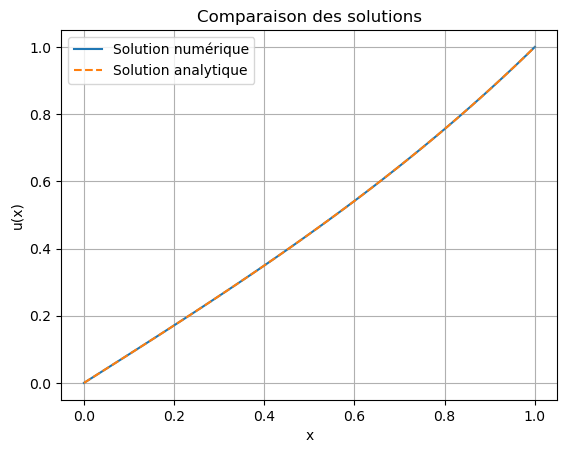

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# Paramètres physiques
mu = 1.0  # Diffusivité
gamma = 1.0  # Réaction

# Paramètres numériques
N = 50  # Nombre de points
h = 1 / N  # Pas d'espace
x = np.linspace(0, 1, N+1)  # Maillage

# Construction de la matrice tridiagonale A
diag_main = 2 + (gamma * h**2 / mu) * np.ones(N-1)
diag_lower = -1 * np.ones(N-2)
diag_upper = -1 * np.ones(N-2)
A = diags([diag_lower, diag_main, diag_upper], offsets=[-1, 0, 1], format="csc")

# Construction du vecteur source F
F = np.zeros(N-1)
F[-1] = 1  # Contribution de la condition u(1) = 1

# Résolution du système linéaire
U_internal = spsolve(A, F)

# Ajout des conditions aux limites
U = np.zeros(N+1)
U[1:N] = U_internal
U[-1] = 1

# Solution analytique
lambda_ = np.sqrt(gamma / mu)
U_exact = np.sinh(lambda_ * x) / np.sinh(lambda_)

# Affichage des résultats
plt.plot(x, U, label="Solution numérique")
plt.plot(x, U_exact, label="Solution analytique", linestyle="dashed")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Comparaison des solutions")
plt.legend()
plt.grid()
plt.show()


In [1]:
# IMPORTATION DES LIBRAIRIES
# ==========================
from sympy import symbols, Function, Eq, dsolve

# DÉFINITION DES VARIABLES
x = symbols('x')  # Variable indépendante
lambda_ = symbols('lambda')  # Paramètre constant
u = Function('u')  # Solution inconnue

# DÉFINITION DE L'ÉQUATION DIFFÉRENTIELLE
edo = Eq(u(x).diff(x, 2) - lambda_**2 * u(x), 0)

# RÉSOLUTION DE L'ÉQUATION
solution = dsolve(edo)
print("Solution générale de l'EDO :", solution)


Solution générale de l'EDO : Eq(u(x), C1*exp(-lambda*x) + C2*exp(lambda*x))


In [3]:
from sympy import symbols, Function, Eq, dsolve, exp

# Define variables and function
x = symbols('x')
y = Function('y')
mu, gamma = symbols('mu gamma')

# Define the equation
edp = Eq(-mu * y(x).diff(x, 2) + gamma * y(x).diff(x), 0)

# Solve the equation with boundary conditions
solution_analytique = dsolve(edp, ics={y(0): 0, y(1): 1})

# Display the solution
print("Solution particulière de l'EDO avec condition initiale:\n", solution_analytique)


Solution particulière de l'EDO avec condition initiale:
 Eq(y(x), exp(gamma*x/mu)/(exp(gamma/mu) - 1) - 1/(exp(gamma/mu) - 1))


In [4]:
solution_analytique

Eq(y(x), exp(gamma*x/mu)/(exp(gamma/mu) - 1) - 1/(exp(gamma/mu) - 1))

## 2. Écrire un programme simulant la solution de (5) et la comparer à la solution exacte, pour le même pas d’espace $h$ et pour un choix de $\mu$ et $\gamma$, tel que :  
   - a) $\frac{\gamma}{6\mu} \ll 1$  
   - b) $\frac{\gamma}{6\mu} \gg 1$  

   Ce nombre est le **Péclet**, qui mesure le rapport entre les phénomènes diffusifs et réactifs.  
   - S’il est $\gg 1$, c’est la réaction qui domine sur la diffusion.  
   - S’il est $\ll 1$, c’est la diffusion qui domine. 


In [8]:
# =============================================
# Résolution de l'Équation de Diffusion-Réaction Généralisée
# -μd²u/dx² + γc(x)u = f avec x dans ]0 ,1[, avec
# −μu′′(x)+γu(x)=0,avec u(0)=0 et u(1)=1.
# f(x)=0 et c(x)= γ
# et les conditions aux limites u(0) = 0, u(1) = 1
# ==============================================

In [9]:
# IMPORTATION DES LIBRAIRIES
# ==========================
import numpy as np
from sympy import symbols, Function, Eq, dsolve, exp
from sympy.abc import x, C
from scipy.sparse import dia_matrix
import sympy as sp
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve
from scipy.linalg import norm

In [ ]:
# MAILLAGE DU DOMAINE
# =============================
# Discrétisation du domaine spatial avec un pas dx.

def maillage_domaine(NX): 
    """
    Génère le maillage du domaine spatial.
    """
    x = np.linspace(0, 1, NX)  # Positions discrètes sur le domaine [0,1]
    dx = 1 / (NX - 1)  # Pas de discrétisation
    return x, dx


In [ ]:
NX = 10
x, dx = maillage_domaine(NX)

In [ ]:
# DÉFINITION DES FONCTIONS
# =========================
def func_f(x):
    return 0  # Fonction source f(x)

def func_c(x):
    return lambda_  # Coefficient c(x)

def solution_exacte(x, alpha, beta):
    # return (x**3/6 - x**2/4 + x/4 - np.exp(2)/(-6 + 6*np.exp(2)))*np.exp(x) + np.exp(2)*np.exp(-x)/(-6 + 6*np.exp(2))
    return (x**3/6 - x**2/4 + x/4 - np.exp(2)/(-6 + 6*np.exp(2)))*np.exp(x) + np.exp(2)*np.exp(-x)/(-6 + 6*np.exp(2))

f = np.vectorize(func_f)
c = np.vectorize(func_c)